In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, random_split
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns

### 1. Завантаження даних

In [2]:
def get_gpu():
    if torch.cuda.is_available():
        return "cuda"
    if torch.backends.mps.is_available():
        return "mps"
    else:
        return "cpu"

In [3]:
device = get_gpu()

device

'mps'

In [4]:
class BreastCancerDataset(Dataset):
    def __init__(self, filename):
        self.dataframe = self._preprocess(pd.read_csv(filename)) 

    def __len__(self):
        return len(self.dataframe)
    
    def _preprocess(self, dataframe):
        dataframe["diagnosis"] = dataframe["diagnosis"].apply(lambda d: 1 if d == "M" else 0)

        return dataframe
    
    def __getitem__(self, index):
        x = self.dataframe.drop(columns=["diagnosis", "id"]).iloc[index].values
        y = self.dataframe["diagnosis"].iloc[index]

        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.long)

        return (x, y)

In [5]:
dataset = BreastCancerDataset(filename="./breast_cancer.csv")

In [6]:
train_size = int(len(dataset) * 0.8)
valid_size = int(len(dataset) * 0.1)
test_size = len(dataset) - train_size - valid_size

train_size, valid_size, test_size

(455, 56, 58)

In [7]:
generator = torch.Generator().manual_seed(42)

train_dataset, valid_dataset, test_dataset = random_split(
    dataset, 
    [train_size, valid_size, test_size],
    generator=generator)

In [8]:
BATCH_SIZE = 32

train_loader = DataLoader(
    dataset = train_dataset,
    batch_size = BATCH_SIZE,
    shuffle=True,
)

valid_loader = DataLoader(
    dataset = valid_dataset,
    batch_size = BATCH_SIZE,
    shuffle=False,
)

test_loader = DataLoader(
    dataset = test_dataset,
    batch_size = BATCH_SIZE,
    shuffle=False,
)

### 2. Розробка глибокої архітектури

In [9]:
class MLPBlock(nn.Module):
    def __init__(self, in_features, out_features, use_bn=True, dropout_p=0.0):
        super().__init__()
        layers = []
        layers.append(nn.Linear(in_features, out_features))
        
        if use_bn:
            layers.append(nn.BatchNorm1d(out_features))
            
        layers.append(nn.ReLU(inplace=True))
        
        if dropout_p > 0:
            layers.append(nn.Dropout(p=dropout_p))

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

In [10]:
class MLPv1(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        
        self.block1 = MLPBlock(in_features=in_features, out_features=16, use_bn=False)
        self.block2 = MLPBlock(in_features=16, out_features=32, use_bn=False)
        self.block3 = MLPBlock(in_features=32, out_features=64, use_bn=False)
        self.block4 = MLPBlock(in_features=64, out_features=128, use_bn=False)

        self.dense = nn.Linear(in_features=128, out_features=out_features)

    def forward(self, X):
        X = self.block1(X)
        X = self.block2(X)
        X = self.block3(X)
        X = self.block4(X)
        
        return self.dense(X)

In [11]:
n = dataset.dataframe.shape[0]
d = dataset.dataframe.shape[1] - 2
classes = len(dataset.dataframe["diagnosis"].value_counts())

n, d, classes

(569, 30, 2)

In [12]:
model = MLPv1(in_features=d, out_features=classes).to(device)

model

MLPv1(
  (block1): MLPBlock(
    (block): Sequential(
      (0): Linear(in_features=30, out_features=16, bias=True)
      (1): ReLU(inplace=True)
    )
  )
  (block2): MLPBlock(
    (block): Sequential(
      (0): Linear(in_features=16, out_features=32, bias=True)
      (1): ReLU(inplace=True)
    )
  )
  (block3): MLPBlock(
    (block): Sequential(
      (0): Linear(in_features=32, out_features=64, bias=True)
      (1): ReLU(inplace=True)
    )
  )
  (block4): MLPBlock(
    (block): Sequential(
      (0): Linear(in_features=64, out_features=128, bias=True)
      (1): ReLU(inplace=True)
    )
  )
  (dense): Linear(in_features=128, out_features=2, bias=True)
)

### 3. Тренування

In [13]:
def l1_regularization(model):
    return sum(p.abs().sum() for name, p in model.named_parameters() if 'weight' in name)

def l2_regularization(model):
    return sum((p**2).sum() for name, p in model.named_parameters() if 'weight' in name)

In [14]:
criterion = nn.CrossEntropyLoss()

def compute_loss(y_hat, y_true, model=None, use_l1=False, use_l2=False, alpha=0.01):
    base_loss = criterion(y_hat, y_true)
    
    reg_loss = 0
    if model is not None:
        if use_l1:
            reg_loss += alpha * l1_regularization(model)
        if use_l2:
            reg_loss += alpha * l2_regularization(model)
            
    return base_loss + reg_loss

In [15]:
def train_model(
        model, optimizer, train_loader, valid_loader, 
        use_l1=False, use_l2=False, alpha=0.01, max_epochs=50, scheduler = None, early_stopping=None
    ):
    history = {
        "train_loss": [],
        "valid_loss": [],
        "train_acc": [],
        "valid_acc": []
    }
    
    n_epochs_wihout_impr = 0
    min_v_loss = torch.inf

    for epoch in range(max_epochs):
        model.train() 
        train_loss, train_correct, train_total = 0, 0, 0
        
        for X_batch, y_batch in train_loader:

            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            logits = model(X_batch)
            l = compute_loss(logits, y_batch, model, use_l1, use_l2, alpha)

            optimizer.zero_grad() 
            l.backward()          
            optimizer.step()    

            train_loss += l.item()
            _, predicted = torch.max(logits.data, 1)
            train_total += y_batch.size(0)
            train_correct += (predicted == y_batch).sum().item()

        model.eval() 
        valid_loss, valid_correct, valid_total = 0, 0, 0
        
        with torch.no_grad():
            for X_valid, y_valid in valid_loader:
                X_valid, y_valid = X_valid.to(device), y_valid.to(device)

                v_logits = model(X_valid)
                v_l = compute_loss(v_logits, y_valid)

                valid_loss += v_l.item()
                _, v_predicted = torch.max(v_logits.data, 1)
                valid_total += y_valid.size(0)
                valid_correct += (v_predicted == y_valid).sum().item()

     

        t_loss = train_loss / len(train_loader)
        v_loss = valid_loss / len(valid_loader)

        if scheduler is not None:
            scheduler.step(v_loss)

        t_acc = 100 * train_correct / train_total
        v_acc = 100 * valid_correct / valid_total

        history["train_loss"].append(t_loss)
        history["valid_loss"].append(v_loss)
        history["train_acc"].append(t_acc)
        history["valid_acc"].append(v_acc)

        if early_stopping is not None:
            if v_loss < min_v_loss:
                min_v_loss = v_loss
                n_epochs_wihout_impr = 0
            else:
                n_epochs_wihout_impr += 1
            
            if n_epochs_wihout_impr >= early_stopping:
                return history
              
    return history 

In [16]:
def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)
    
    best_v_loss = min(history["valid_loss"])
    best_v_acc = max(history["valid_acc"])
    
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["valid_loss"], label="Valid Loss")
    
    plt.axhline(y=best_v_loss, color='grey', linestyle='--', alpha=0.6)
    plt.text(len(epochs), best_v_loss, f' Min: {best_v_loss:.4f}', 
             va='bottom', color='grey', fontweight='bold')
    
    plt.title("Loss Curves")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["valid_acc"], label="Valid Acc")
    
    plt.axhline(y=best_v_acc, color='grey', linestyle='--', alpha=0.6)
    plt.text(len(epochs), best_v_acc, f' Max: {best_v_acc:.2f}%', 
             va='top', color='grey', fontweight='bold')
    
    plt.title("Accuracy Curves")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy (%)")
    plt.ylim(None, 105) 
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [17]:
def plot_lrs_grid(histories, lrs):
    num_lrs = len(lrs)
    epochs = np.arange(1, len(histories[0]["train_loss"]) + 1)
    
    plt.figure(figsize=(14, 5 * num_lrs))

    for i, (history, lr) in enumerate(zip(histories, lrs)):
        v_loss = history["valid_loss"]
        v_acc = history["valid_acc"]
        
        best_loss = min(v_loss)
        best_loss_epoch = epochs[np.argmin(v_loss)]
        
        best_acc = max(v_acc)
        best_acc_epoch = epochs[np.argmax(v_acc)]

        plt.subplot(num_lrs, 2, 2 * i + 1)
        plt.plot(epochs, history["train_loss"], label="Train Loss", color='tab:blue')
        plt.plot(epochs, v_loss, label="Valid Loss", color='tab:orange', linestyle='--')
        
        plt.axhline(y=best_loss, color='grey', linestyle=':', alpha=0.6)
        plt.text(best_loss_epoch, best_loss, f' Min: {best_loss:.4f}', 
                 va='bottom', color='grey', fontweight='bold')
        
        plt.title(f"Loss Curves (LR: {lr})")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.yscale('log') 
        plt.legend()
        plt.grid(True, alpha=0.2)

        plt.subplot(num_lrs, 2, 2 * i + 2)
        plt.plot(epochs, history["train_acc"], label="Train Acc", color='tab:blue')
        plt.plot(epochs, v_acc, label="Valid Acc", color='tab:orange', linestyle='--')
        
        plt.axhline(y=best_acc, color='grey', linestyle=':', alpha=0.6)
        plt.text(best_acc_epoch, best_acc, f' Max: {best_acc:.2f}%', 
                 va='top', color='grey', fontweight='bold')
        
        plt.title(f"Accuracy Curves (LR: {lr})")
        plt.xlabel("Epochs")
        plt.ylabel("Accuracy (%)")
        plt.ylim(50, 105) 
        plt.legend()
        plt.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

In [18]:
histories1 = []
learning_rates = [0.01, 0.001, 0.0001]

for lr in learning_rates:
    model = MLPv1(in_features=d, out_features=classes).to(device)
    optimizer = torch.optim.Adam(params=model.parameters(), lr=lr)

    histories1.append(train_model(model, optimizer, train_loader, valid_loader, max_epochs=200))

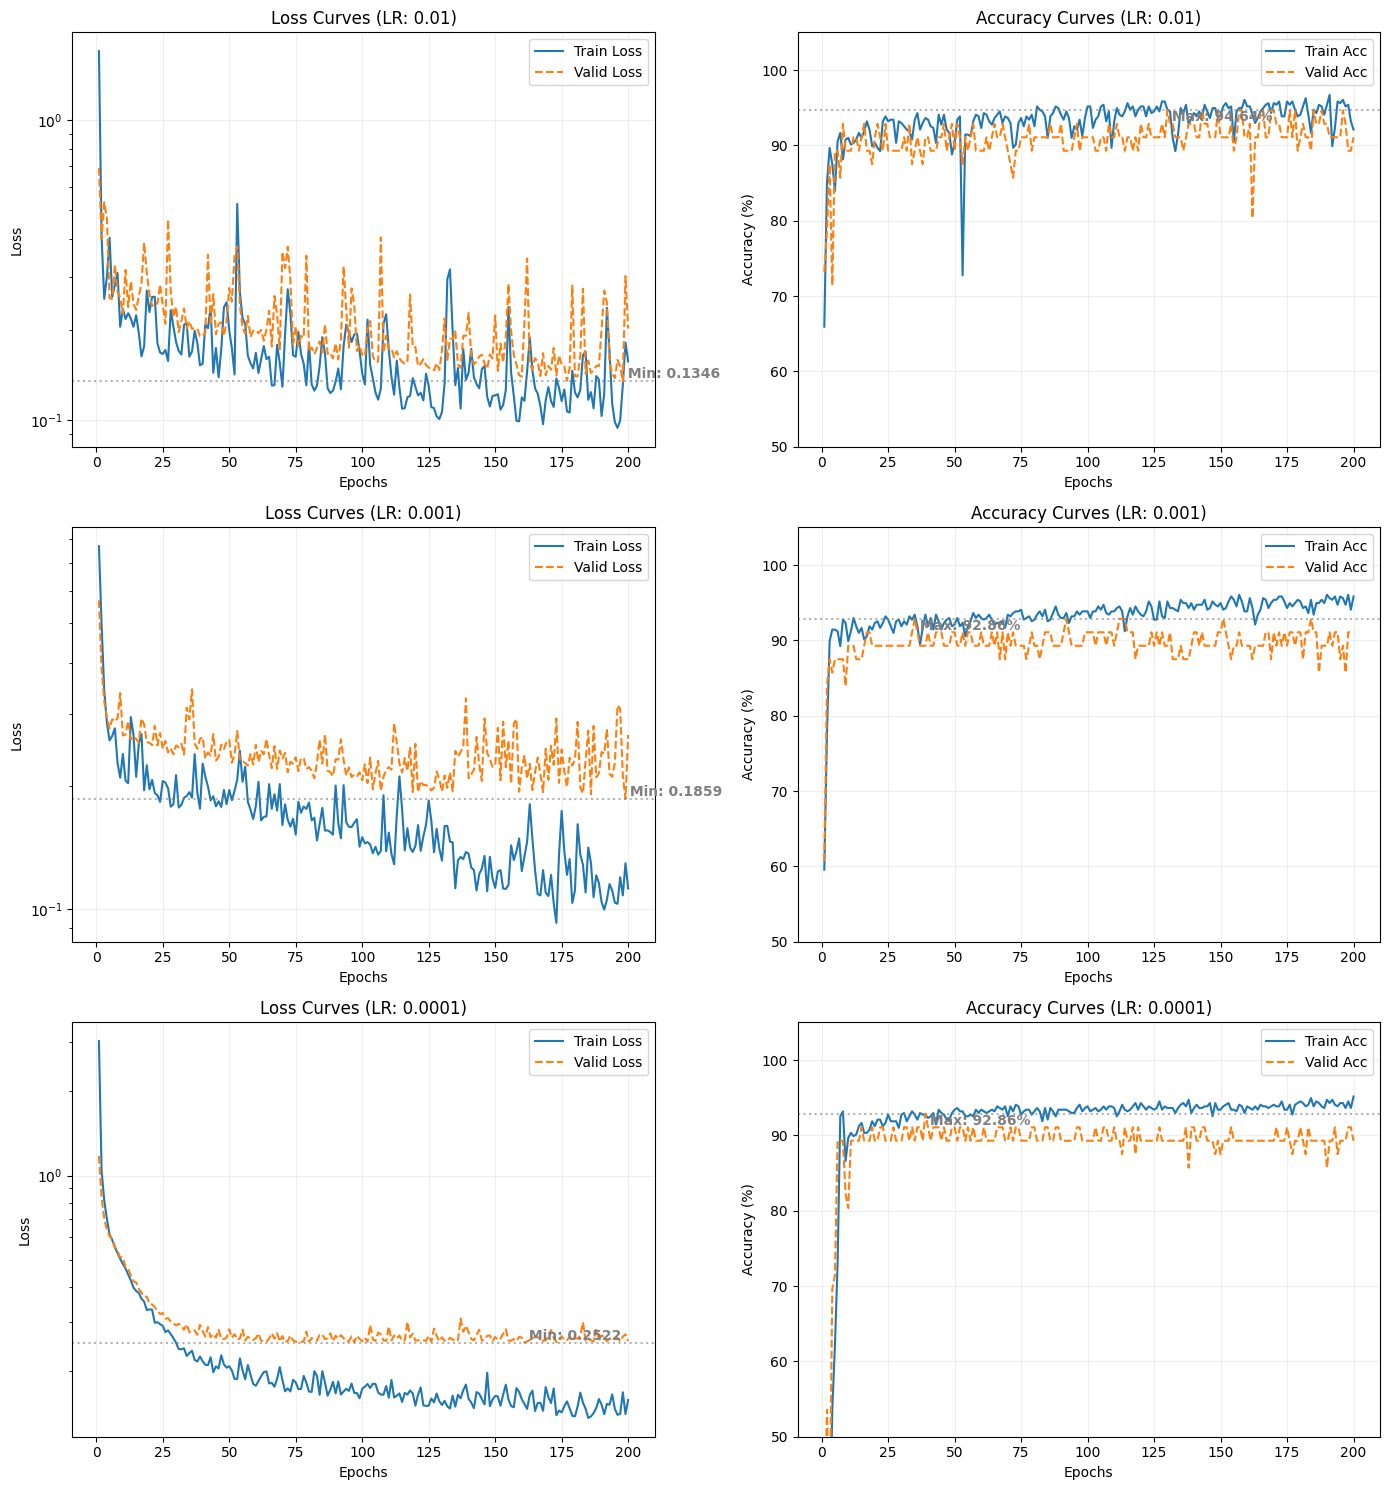

In [19]:
plot_lrs_grid(histories1, learning_rates)

In [20]:
class MLPv2(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        
        self.block1 = MLPBlock(in_features=in_features, out_features=16)
        self.block2 = MLPBlock(in_features=16, out_features=32)
        self.block3 = MLPBlock(in_features=32, out_features=64, dropout_p=0.5)
        self.block4 = MLPBlock(in_features=64, out_features=128, dropout_p=0.5)

        self.dense = nn.Linear(in_features=128, out_features=out_features)

    def forward(self, X):
        X = self.block1(X)
        X = self.block2(X)
        X = self.block3(X)
        X = self.block4(X)
        
        return self.dense(X)

In [21]:
histories2 = []

for lr in learning_rates:
    model = MLPv2(in_features=d, out_features=classes).to(device)
    optimizer = torch.optim.Adam(params=model.parameters(), lr=lr)

    histories2.append(train_model(model, optimizer, train_loader, valid_loader, max_epochs=200))

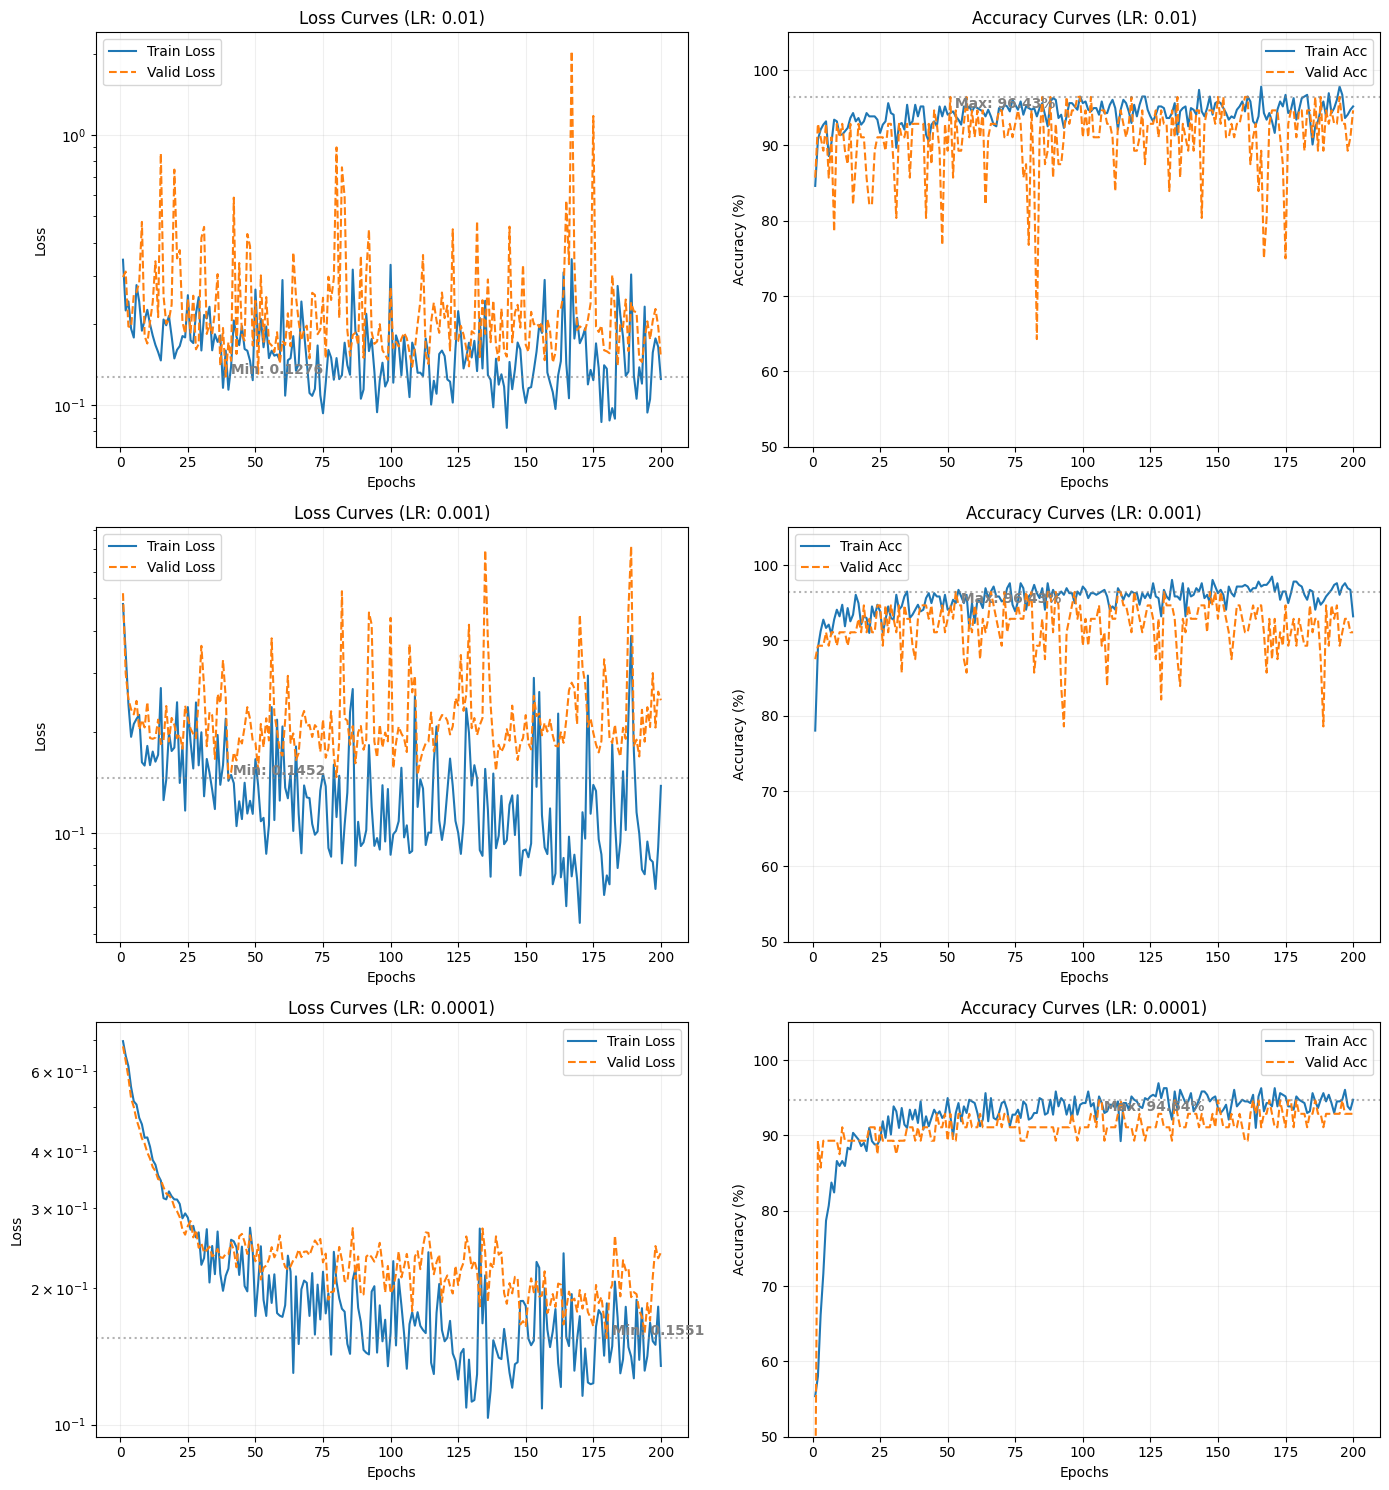

In [22]:
plot_lrs_grid(histories2, learning_rates)

In [23]:
def evaluate_final_model(model, test_loader, device):
    model.eval()
    y_true = []
    y_pred = []
    y_probs = [] 
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            
            _, predicted = torch.max(outputs, 1)
            
            probs = torch.softmax(outputs, dim=1)
            
            y_true.extend(y_batch.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
            y_probs.extend(probs[:, 1].cpu().numpy()) 
            
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Benign', 'Malignant'], 
                yticklabels=['Benign', 'Malignant'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Final Test Set Confusion Matrix')

    fpr, tpr, thresholds = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.subplot(1, 2, 2)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') 
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity/Recall)')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    
    print(classification_report(y_true, y_pred, target_names=['Benign', 'Malignant']))

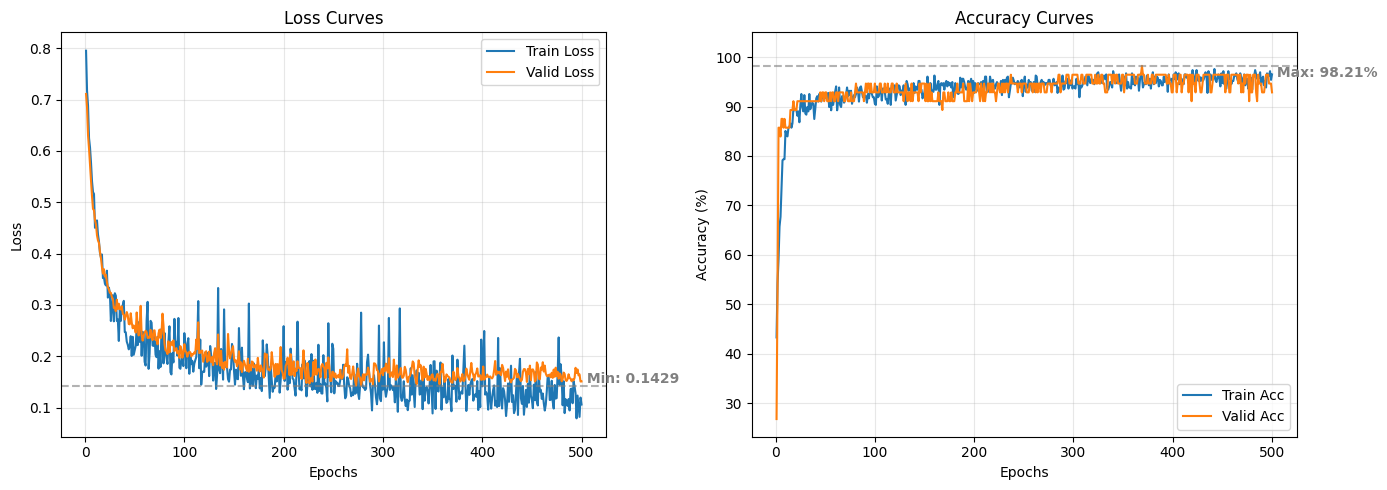

In [24]:
LEARNING_RATE = 0.0001

model = MLPv2(in_features=d, out_features=classes).to(device)
optimizer = torch.optim.Adam(params=model.parameters(), lr=LEARNING_RATE)

history = train_model(model, optimizer, train_loader, valid_loader, max_epochs=500)

plot_history(history)

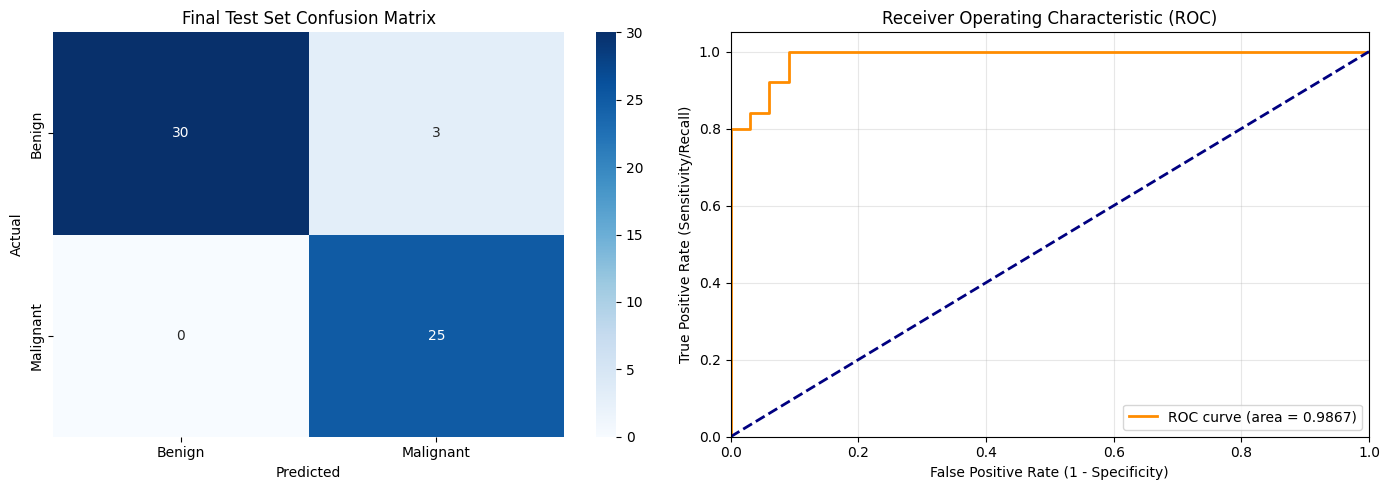

              precision    recall  f1-score   support

      Benign       1.00      0.91      0.95        33
   Malignant       0.89      1.00      0.94        25

    accuracy                           0.95        58
   macro avg       0.95      0.95      0.95        58
weighted avg       0.95      0.95      0.95        58



In [26]:
evaluate_final_model(model, test_loader, device)

### 4. Регуляризація

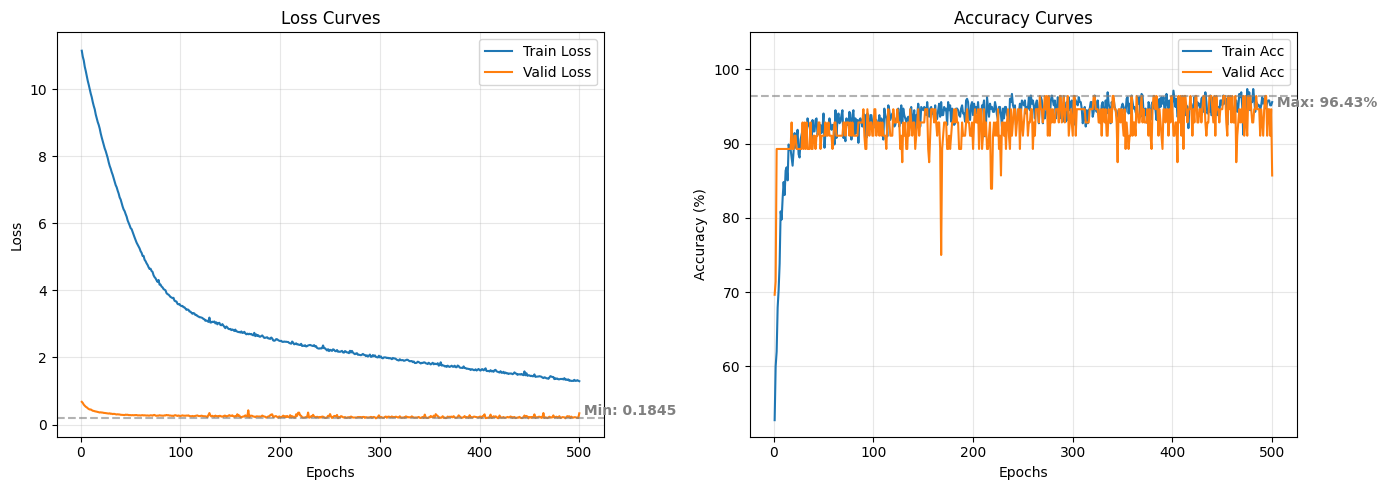

In [27]:
LEARNING_RATE = 0.0001

model = MLPv2(in_features=d, out_features=classes).to(device)
optimizer = torch.optim.Adam(params=model.parameters(), lr=LEARNING_RATE)

history = train_model(model, optimizer, train_loader, valid_loader, use_l1=True, max_epochs=500)

plot_history(history)

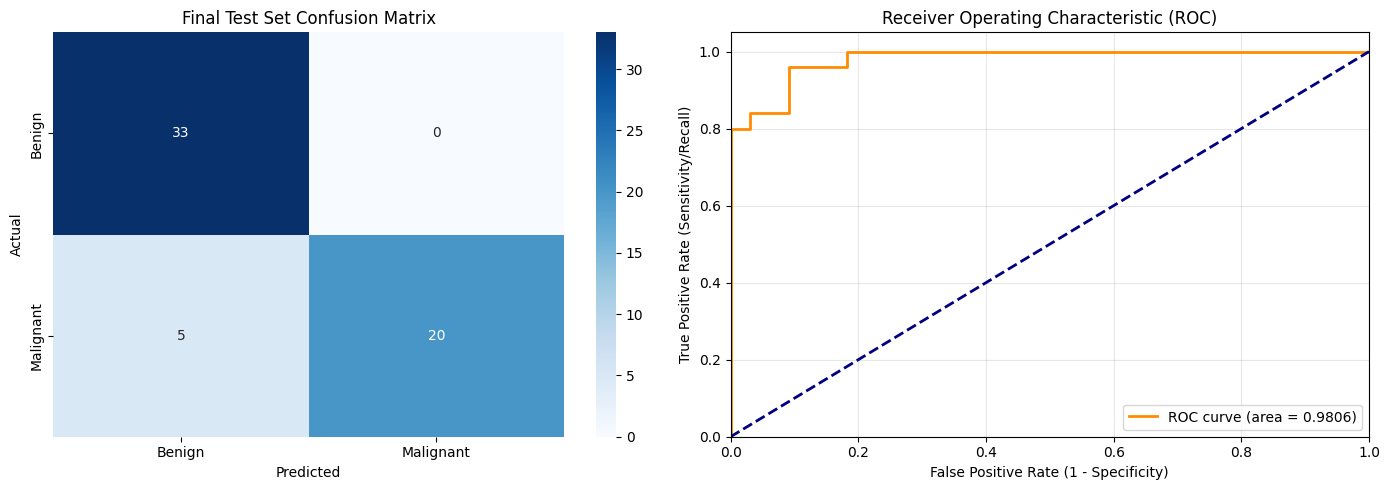

              precision    recall  f1-score   support

      Benign       0.87      1.00      0.93        33
   Malignant       1.00      0.80      0.89        25

    accuracy                           0.91        58
   macro avg       0.93      0.90      0.91        58
weighted avg       0.93      0.91      0.91        58



In [28]:
evaluate_final_model(model, test_loader, device)

In [29]:
model.state_dict()

OrderedDict([('block1.block.0.weight',
              tensor([[-5.1998e-06, -3.0843e-04, -1.8745e-05,  2.5117e-04,  5.8556e-06,
                       -2.4134e-05, -1.8558e-05, -1.0451e-06, -1.5511e-05, -9.1955e-07,
                       -2.6955e-05,  1.7064e-05,  8.3287e-06, -6.7270e-04, -8.1927e-06,
                        8.8143e-06,  1.3182e-05, -1.3512e-05,  9.0129e-06, -9.7824e-06,
                        8.1423e-06, -3.2564e-04, -1.3813e-05,  4.4604e-03, -5.7523e-06,
                       -5.4327e-06, -1.3399e-05,  1.6152e-05,  4.6939e-06,  1.0813e-05],
                      [-1.1895e-05, -7.2051e-06, -3.2055e-06,  4.5903e-04,  9.0233e-07,
                       -1.0058e-05, -8.4850e-06, -4.5505e-06,  2.8924e-05, -6.9278e-06,
                       -2.0649e-05,  7.2419e-06, -3.1806e-05,  1.0297e-02,  1.2728e-05,
                        6.5315e-06, -8.3024e-06,  2.3898e-05, -1.0222e-05,  5.1006e-06,
                       -4.2088e-06, -1.4117e-05, -1.1382e-05, -4.6278e-03, -1.26

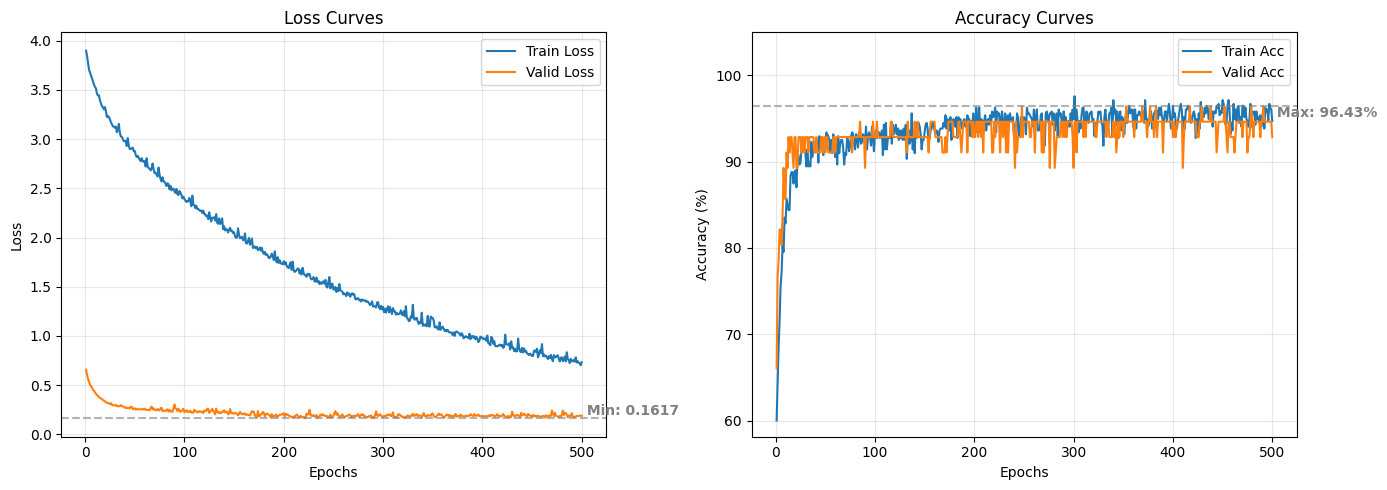

In [30]:
LEARNING_RATE = 0.0001

model = MLPv2(in_features=d, out_features=classes).to(device)
optimizer = torch.optim.Adam(params=model.parameters(), lr=LEARNING_RATE)

history = train_model(model, optimizer, train_loader, valid_loader, use_l2=True, max_epochs=500)

plot_history(history)

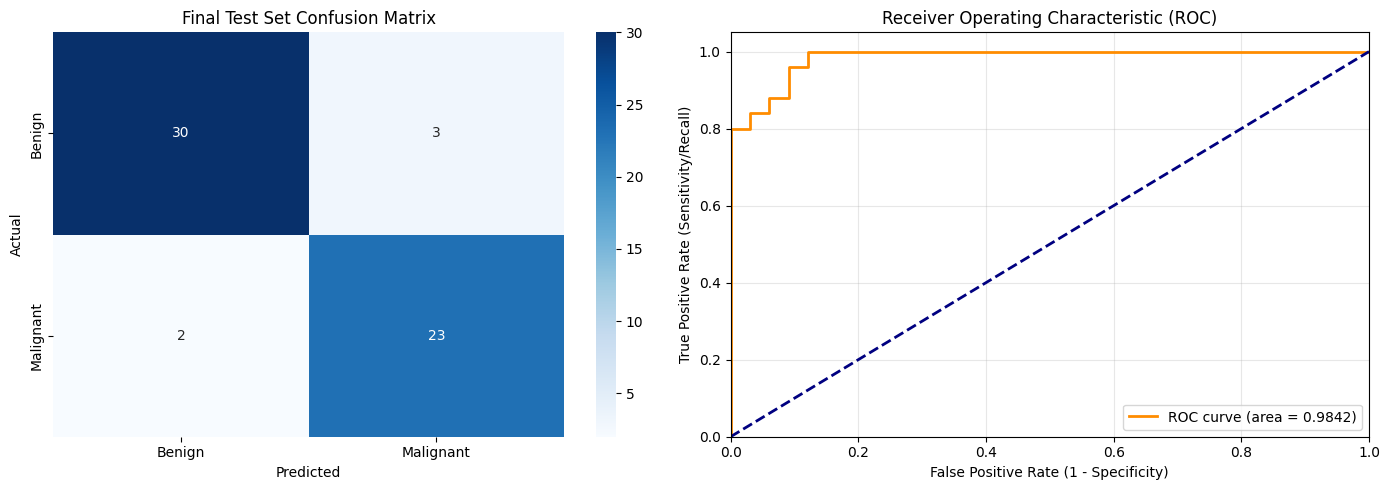

              precision    recall  f1-score   support

      Benign       0.94      0.91      0.92        33
   Malignant       0.88      0.92      0.90        25

    accuracy                           0.91        58
   macro avg       0.91      0.91      0.91        58
weighted avg       0.91      0.91      0.91        58



In [32]:
evaluate_final_model(model, test_loader, device)

In [33]:
model.state_dict()

OrderedDict([('block1.block.0.weight',
              tensor([[ 1.9344e-03, -3.2536e-02,  7.4159e-03,  2.9561e-02, -1.3915e-04,
                       -1.3741e-04, -1.1473e-03, -4.5414e-04, -4.4907e-05, -3.3649e-05,
                        1.2068e-03,  4.5558e-03,  7.8713e-03, -4.6240e-02, -4.7636e-05,
                        2.5870e-06, -2.1147e-04, -9.8421e-06, -4.1769e-05,  2.2093e-05,
                        4.7875e-03, -1.8072e-02,  2.9172e-04,  1.0995e-01, -5.3750e-04,
                       -1.0156e-03, -2.9384e-03, -7.6641e-04, -6.7215e-04, -1.3428e-04],
                      [-2.9265e-03,  2.7616e-02,  1.1923e-02,  1.2366e-01,  1.8488e-04,
                        2.0024e-04,  1.7225e-03,  6.4503e-04,  2.1282e-04,  3.1393e-05,
                        8.8871e-05, -6.1161e-03, -7.8177e-03, -4.4589e-02,  1.8029e-05,
                        1.6965e-05,  2.9859e-04,  2.6551e-05,  1.1765e-04,  1.5984e-05,
                       -2.1534e-03,  1.2204e-02,  8.8991e-03,  8.0292e-02,  7.34

### 5. Оптимізація

In [34]:
def plot_optimizer_comparison(histories, names):
    num_opts = len(names)
    epochs = np.arange(1, len(histories[0]["train_loss"]) + 1)
    
    plt.figure(figsize=(16, 5 * num_opts))

    for i, (history, name) in enumerate(zip(histories, names)):
        best_v_loss = min(history["valid_loss"])
        best_v_acc = max(history["valid_acc"])

        plt.subplot(num_opts, 2, 2 * i + 1)
        plt.plot(epochs, history["train_loss"], label="Train", color='royalblue', alpha=0.8)
        plt.plot(epochs, history["valid_loss"], label="Valid", color='darkorange', linestyle='--')
        
        plt.axhline(y=best_v_loss, color='black', linestyle=':', alpha=0.4)
        plt.text(len(epochs), best_v_loss, f' Min: {best_v_loss:.4f}', va='bottom', fontsize=10)
        
        plt.title(f"Loss: {name}", fontsize=14, fontweight='bold')
        plt.yscale('log')
        plt.ylabel("Loss")
        plt.legend(loc='upper right')
        plt.grid(True, alpha=0.2)

        plt.subplot(num_opts, 2, 2 * i + 2)
        plt.plot(epochs, history["train_acc"], label="Train", color='royalblue', alpha=0.8)
        plt.plot(epochs, history["valid_acc"], label="Valid", color='darkorange', linestyle='--')
        
        plt.axhline(y=best_v_acc, color='black', linestyle=':', alpha=0.4)
        plt.text(len(epochs), best_v_acc, f' Max: {best_v_acc:.2f}%', va='top', fontsize=10)
        
        plt.title(f"Accuracy: {name}", fontsize=14, fontweight='bold')
        plt.ylabel("Accuracy (%)")
        plt.ylim(50, 102)
        plt.legend(loc='lower right')
        plt.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()


In [35]:
optimizers = [
    torch.optim.Adam,
    torch.optim.SGD,
    torch.optim.RMSprop
]

histories = []
opt_names = ["Adam", "SGD + Momentum", "RMSprop"]

for i, opt_class in enumerate(optimizers):
    model = MLPv2(in_features=d, out_features=classes).to(device)
    
    if opt_class == torch.optim.SGD:
        optimizer = opt_class(params=model.parameters(), lr=LEARNING_RATE, momentum=0.9)
    else:
        optimizer = opt_class(params=model.parameters(), lr=LEARNING_RATE)

    print(f"Training with {opt_names[i]}...")
    history = train_model(model, optimizer, train_loader, valid_loader, max_epochs=500)
    histories.append(history)

Training with Adam...
Training with SGD + Momentum...
Training with RMSprop...


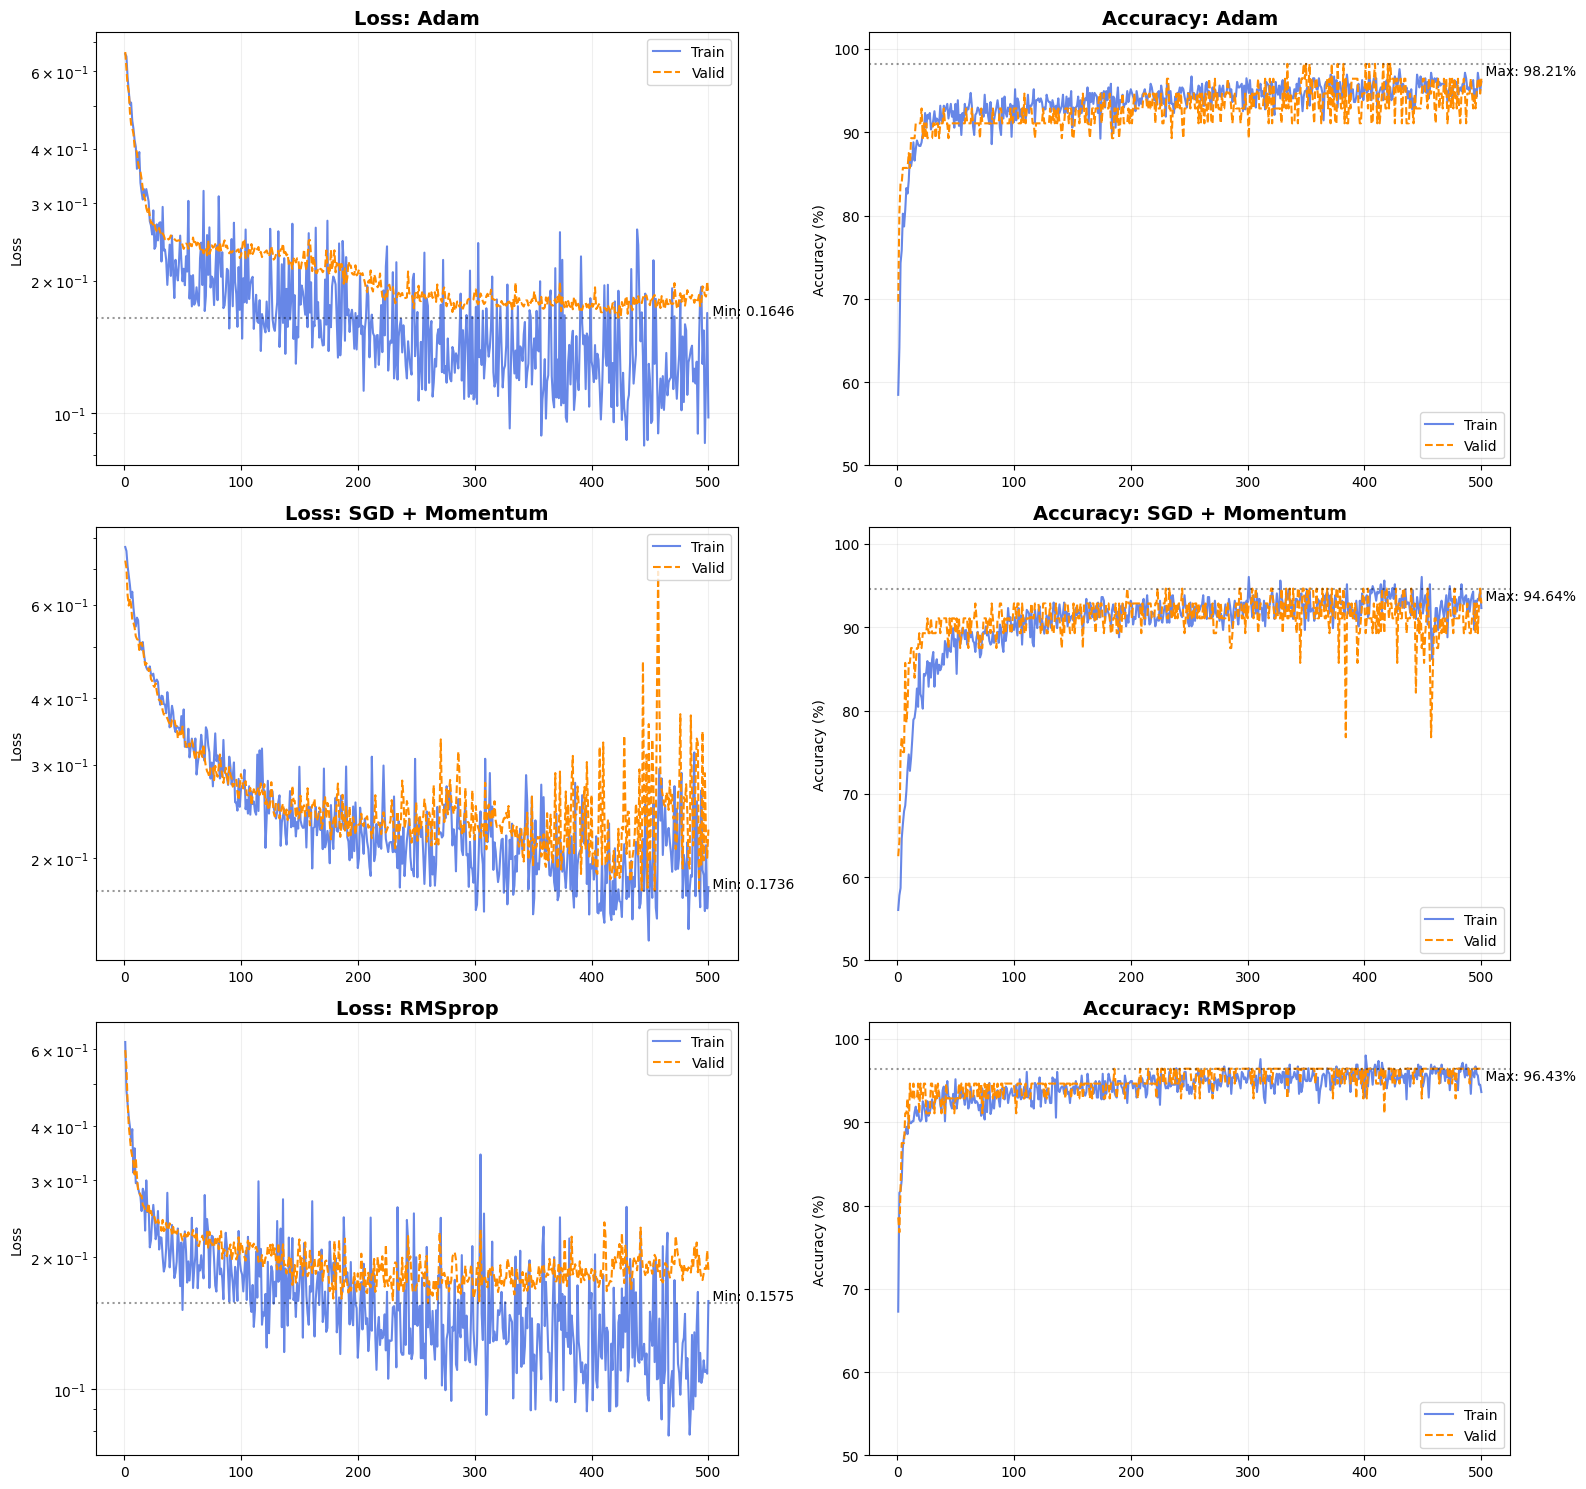

In [36]:
plot_optimizer_comparison(histories, opt_names)

In [37]:
LEARNING_RATE = 0.01

model = MLPv2(in_features=d, out_features=classes).to(device)
optimizer = torch.optim.Adam(params=model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer=optimizer,
    mode="min",
    factor=0.1,
    patience=10
)

history = train_model(model, optimizer, train_loader, valid_loader, use_l2=True, max_epochs=500, scheduler=scheduler)

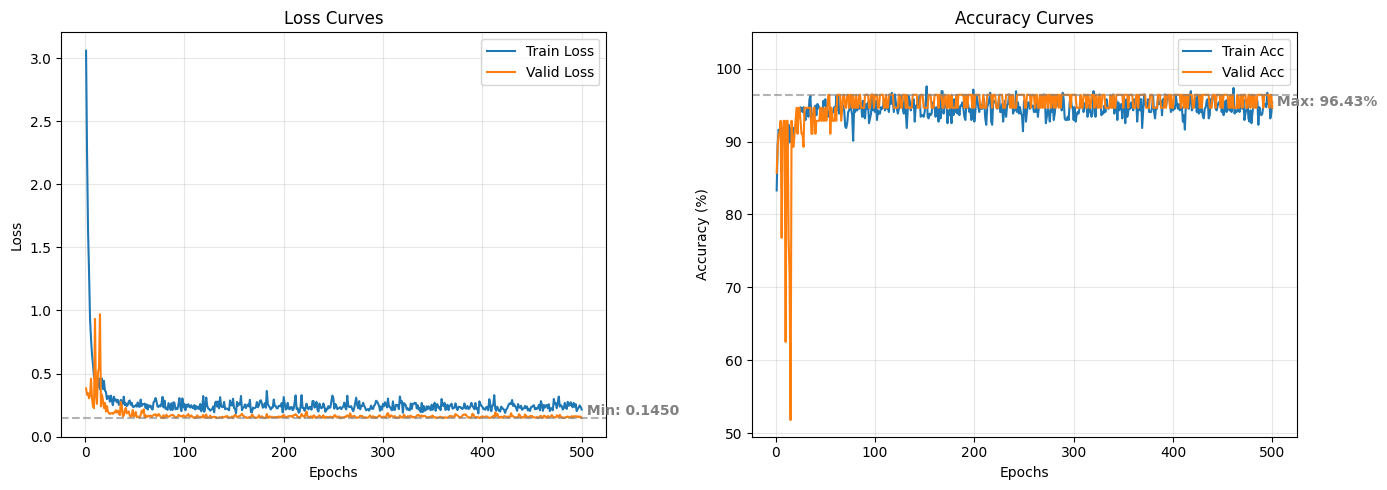

In [38]:
plot_history(history)

### 6. Порівняння моделей

In [39]:
LEARNING_RATE = 0.01

model = MLPv2(in_features=d, out_features=classes).to(device)
optimizer = torch.optim.Adam(params=model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer=optimizer,
    mode="min",
    factor=0.1,
    patience=10
)

history = train_model(model, optimizer, train_loader, valid_loader, use_l2=True, max_epochs=2000, scheduler=scheduler, early_stopping=30)

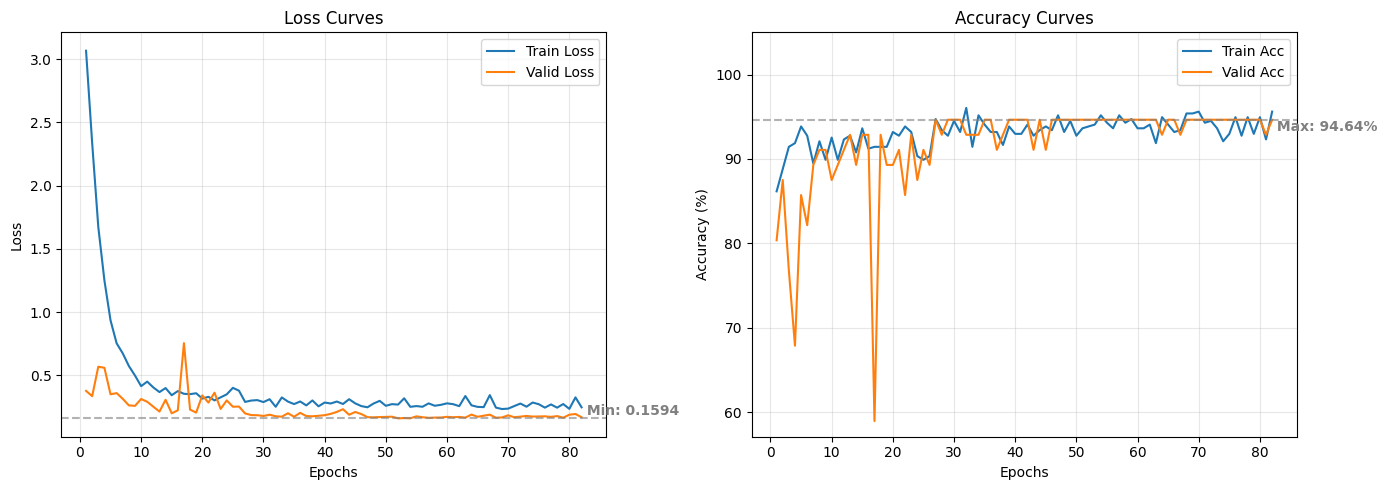

In [40]:
plot_history(history)

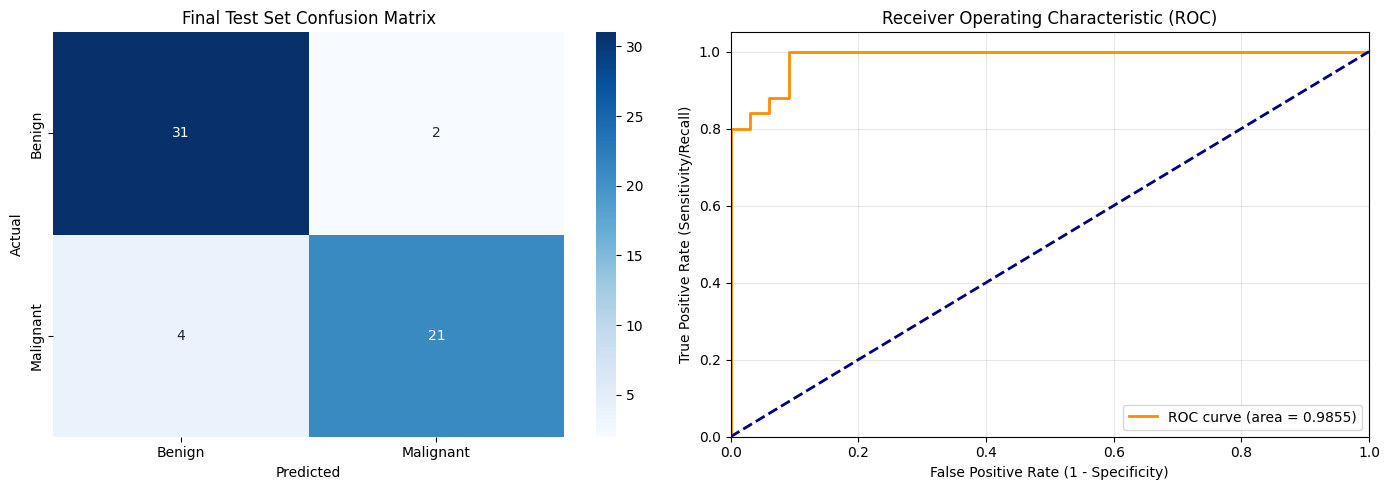

              precision    recall  f1-score   support

      Benign       0.89      0.94      0.91        33
   Malignant       0.91      0.84      0.88        25

    accuracy                           0.90        58
   macro avg       0.90      0.89      0.89        58
weighted avg       0.90      0.90      0.90        58



In [41]:
evaluate_final_model(model, test_loader, device)

In [42]:
LEARNING_RATE = 0.01

model = MLPv1(in_features=d, out_features=classes).to(device)
optimizer = torch.optim.Adam(params=model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer=optimizer,
    mode="min",
    factor=0.1,
    patience=10
)

history = train_model(model, optimizer, train_loader, valid_loader, use_l2=True, max_epochs=2000, scheduler=scheduler, early_stopping=30)

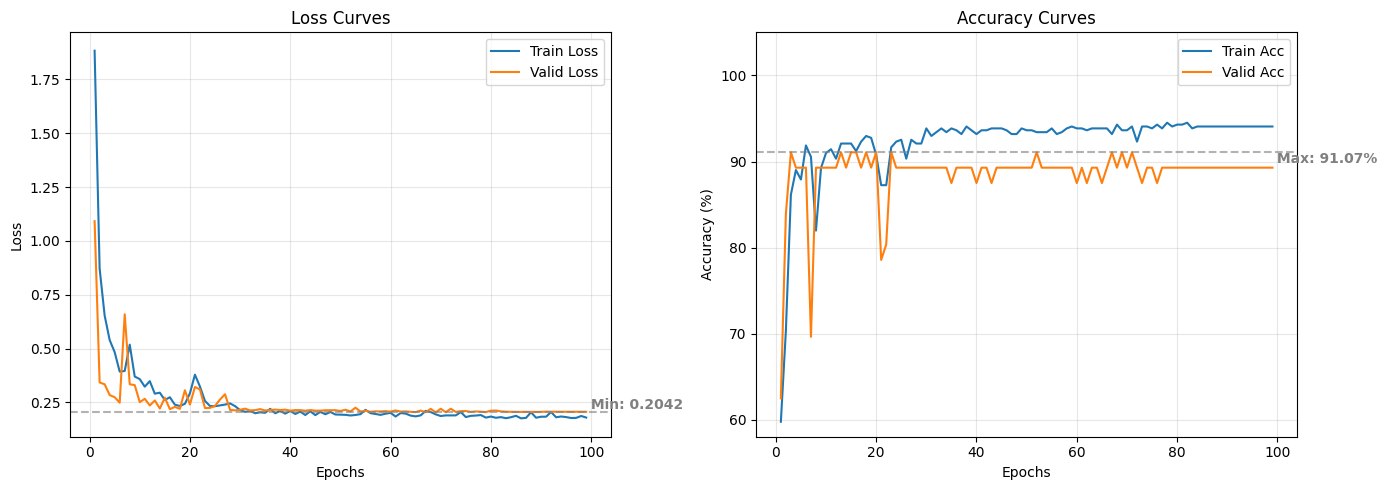

In [44]:
plot_history(history)

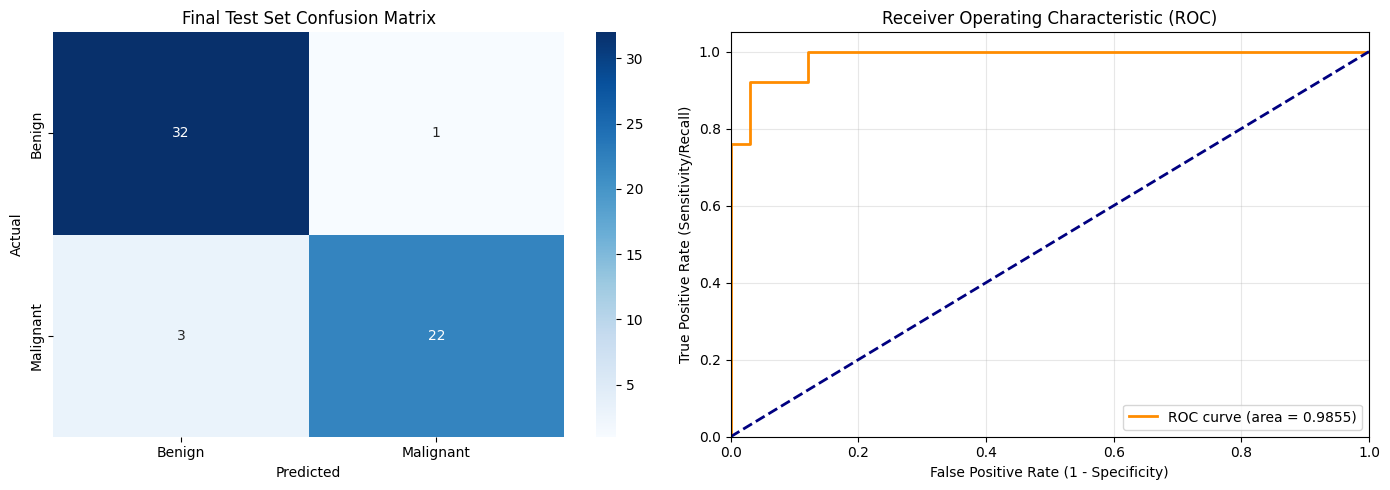

              precision    recall  f1-score   support

      Benign       0.91      0.97      0.94        33
   Malignant       0.96      0.88      0.92        25

    accuracy                           0.93        58
   macro avg       0.94      0.92      0.93        58
weighted avg       0.93      0.93      0.93        58



In [43]:
evaluate_final_model(model, test_loader, device)

### Висновок

Обрана архітектура 4-шарового MLPv2 ($16 \to 128$ нейронів) з активацією ReLU забезпечує ефективне каскадне виділення ознак без затухання градієнтів, а використання оптимізатора Adam із адаптивним кроком (початковий $LR=0.01$ та ReduceLROnPlateau) гарантує швидку та стабільну збіжність до мінімуму. Висока точність моделі (Accuracy ~90%, AUC 0.9855) досягнута завдяки комплексу регуляризації: BatchNorm стабілізував внутрішні шари, Dropout (0.5) та L2-штраф запобігли перенавчанню через обмеження росту ваг і коадаптації нейронів, а механізм Early Stopping на 85-й епосі забезпечив оптимальну здатність до узагальнення. У підсумку поєднання динамічного навчання та жорсткої регуляризації дозволило моделі ефективно розділяти класи з мінімальним розривом між тренувальними та валідаційними втратами.